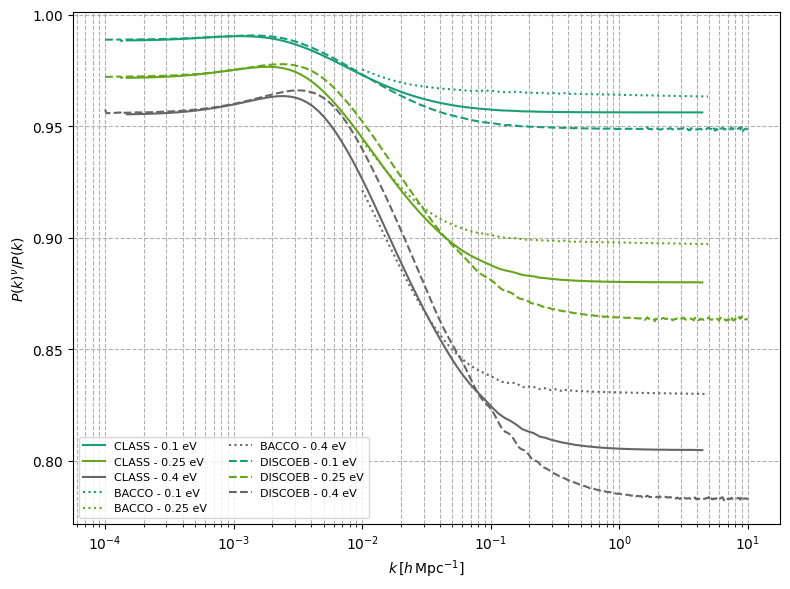

In [ ]:
import jax
jax.config.update("jax_enable_x64", True) # unfortunately we currently require double precision
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# load
class_data = np.load("class_results.npy", allow_pickle=True)
bacco_data = np.load("bacco_results.npy", allow_pickle=True)
discoeb_data = np.load("discoeb_results.npy", allow_pickle=True)
discodj_data = np.load("discodj_results.npy", allow_pickle=True)

all_data = list(class_data) + list(bacco_data) + list(discoeb_data)+ list(discodj_data)

plt.figure(figsize=(8,6))

masses = sorted(set(d["mass"] for d in all_data))
colors = plt.cm.Dark2(np.linspace(0, 1, len(masses)))
mass_to_color = dict(zip(masses, colors))


for d in all_data:
    k = d["k"]
    ratio = d["ratio"]
    mass = d["mass"]
    method = d["method"]

    # style
    if "CLASS" in method:
        ls = "-"
    elif "DISCOEB" in method:
        ls = "--"
    elif "DISCODJ" in method : 
        ls = "dashdot"
    else:
        ls = ":"

    color = mass_to_color[mass]

    plt.semilogx(
        k,
        ratio,
        linestyle=ls,
        color=color,
        label=f"{method} - {mass} eV"
    )

plt.xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^{\nu} / P(k)$')
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()